In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
import matplotlib.pyplot as plt

In [2]:
#--- Random Seeding + Device Checking ---
torch.manual_seed(8)
np.random.seed(8)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
#--- Creating a custom dataset class ---
class SharkFluorescenceDataset(Dataset):
    def __init__(self, csv_path, augment=False, mean=None, std=None):
        # Load CSV
        self.data = pd.read_csv(csv_path)
        
        # Extract species names (labels) from first column
        self.species = self.data.iloc[:, 0].values
        
        # Extract fluorescence values (all columns except first)
        # Shape: (num_samples, num_time_steps)
        self.fluorescence = self.data.iloc[:, 1:].values.astype(np.float32)

        # Normalization
        if mean is None or std is None:
            # Calculate mean and std from this data (for training set)
            self.mean = self.fluorescence.mean()
            self.std = self.fluorescence.std()
        else:
            # Use provided mean and std (for val/test sets)
            self.mean = mean
            self.std = std
        
        # Apply normalization: (x - mean) / std
        self.fluorescence = (self.fluorescence - self.mean) / self.std
        
        # Encode species names to numeric labels
        self.label_encoder = LabelEncoder()
        self.labels = self.label_encoder.fit_transform(self.species)
        
        self.num_classes = len(self.label_encoder.classes_)
        self.augment = augment
        
        print(f"Dataset loaded: {len(self.labels)} samples")
        print(f"Number of species: {self.num_classes}")
        print(f"Time series length: {self.fluorescence.shape[1]}")
        print(f"Augmentation: {'Enabled' if augment else 'Disabled'}")
        print(f"Data normalized with mean={self.mean:.6f}, std={self.std:.6f}")
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        # Get fluorescence values and add channel dimension
        # Shape: (1, num_time_steps) - 1D conv expects (channels, length)
        x = torch.FloatTensor(self.fluorescence[idx]).unsqueeze(0)

        # Apply augmentation if enabled
        if self.augment:
            # Small random noise
            noise = torch.randn_like(x) * 0.01
            x = x + noise
            # Random scaling
            scale = 1 + torch.FloatTensor([np.random.uniform(-0.05, 0.05)])
            x = x * scale
            # Random shift along time axis (small horizontal shift)
            shift = np.random.randint(-5, 6)
            if shift != 0:
                x = torch.roll(x, shifts=shift, dims=1)
        
        # Get label
        y = torch.LongTensor([self.labels[idx]])[0]
        
        return x, y

In [4]:
# --- Residual Block Definition ---
class ResidualBlock1D(nn.Module):
    """
    1D Residual Block with two convolutional layers and a skip connection.
    This allows the network to learn residual functions, making training deeper networks easier.
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, downsample=None):
        super(ResidualBlock1D, self).__init__()
        
        # First convolutional layer
        self.conv1 = nn.Conv1d(
            in_channels, 
            out_channels, 
            kernel_size=kernel_size, 
            stride=stride, 
            padding=kernel_size//2,  # Same padding to maintain dimensions
            bias=False
        )
        self.bn1 = nn.BatchNorm1d(out_channels)  # Normalize activations
        
        # Second convolutional layer
        self.conv2 = nn.Conv1d(
            out_channels, 
            out_channels, 
            kernel_size=kernel_size, 
            stride=1, 
            padding=kernel_size//2,
            bias=False
        )
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        # ReLU activation function
        self.relu = nn.ReLU(inplace=True)
        
        # Downsample layer for skip connection if dimensions don't match
        self.downsample = downsample
    
    def forward(self, x):
        # Store input for skip connection
        identity = x
        
        # First conv -> batch norm -> relu
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        # Second conv -> batch norm
        out = self.conv2(out)
        out = self.bn2(out)
        
        # Apply downsample to identity if needed (to match dimensions)
        if self.downsample is not None:
            identity = self.downsample(x)
        
        # Add skip connection (residual)
        out += identity
        
        # Final activation
        out = self.relu(out)
        
        return out

In [5]:
#--- ResNet1D Definition [with Dropout] ---
class ResNet1D(nn.Module):
    """
    1D ResNet for time-series classification.
    Architecture:
    - Initial conv layer
    - Multiple residual blocks organized in layers
    - Global average pooling
    - Fully connected layer for classification
    """
    def __init__(self, num_classes, input_channels=1, initial_filters=64, dropout=0.65):
        super(ResNet1D, self).__init__()
        
        # Initial convolutional layer
        self.conv1 = nn.Conv1d(
            input_channels, 
            initial_filters, 
            kernel_size=7, 
            stride=2, 
            padding=3, 
            bias=False
        )
        self.bn1 = nn.BatchNorm1d(initial_filters)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        
        # Residual layers (ResNet-18 style: 2 blocks per layer)
        self.layer1 = self._make_layer(initial_filters, initial_filters, blocks=2)
        self.layer2 = self._make_layer(initial_filters, initial_filters*2, blocks=2, stride=2)
        self.layer3 = self._make_layer(initial_filters*2, initial_filters*4, blocks=2, stride=2)
        self.layer4 = self._make_layer(initial_filters*4, initial_filters*8, blocks=2, stride=2)
        
        # Global average pooling - reduces time dimension to 1
        self.avgpool = nn.AdaptiveAvgPool1d(1)

        # Dropout layer: prevents overfitting
        self.dropout = nn.Dropout(dropout)
        
        # Fully connected layer for classification
        self.fc = nn.Linear(initial_filters*8, num_classes)
    
    def _make_layer(self, in_channels, out_channels, blocks, stride=1):
        """
        Create a layer consisting of multiple residual blocks.
        """
        downsample = None
        
        # If dimensions change, we need a downsample layer for the skip connection
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )
        
        layers = []
        # First block (may downsample)
        layers.append(ResidualBlock1D(in_channels, out_channels, stride=stride, downsample=downsample))
        
        # Remaining blocks (no downsampling)
        for _ in range(1, blocks):
            layers.append(ResidualBlock1D(out_channels, out_channels))
        
        return nn.Sequential(*layers)
    
    def forward(self, x):
        # Initial conv layer
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        # Residual layers
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        # Global pooling and flatten
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        
        # Classification layer
        x = self.fc(x)
        
        return x

In [6]:
#--- Training Function ---
def train_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train the model for one epoch.
    """
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in dataloader:
        # Move data to device (GPU/CPU)
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

In [7]:
#--- Evaluation Function ---
def evaluate(model, dataloader, criterion, device):
    """
    Evaluate the model on a dataset.
    """
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    all_predictions = []
    all_labels = []
    
    # No gradient computation during evaluation
    with torch.no_grad():
        for inputs, labels in dataloader:
            # Move data to device
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    total = len(all_labels)
    epoch_loss = running_loss / total
    epoch_acc = 100 * accuracy_score(all_labels, all_predictions)
    
    return epoch_loss, epoch_acc, all_predictions, all_labels

In [8]:
#--- Dataset + K-Fold Cross-Validation Setup ---
from sklearn.model_selection import KFold

dataset = SharkFluorescenceDataset('../../data/shark_dataset.csv', augment=False)

# Setup K-Fold cross-validation
num_folds = 5
kfold = KFold(n_splits=num_folds, shuffle=True, random_state=8)

# Create list of fold indices
fold_indices = list(kfold.split(range(len(dataset))))

print(f"\nK-Fold Setup (K={num_folds}):")
print(f"Total samples: {len(dataset)}")
for fold_num, (train_idx, val_idx) in enumerate(fold_indices):
    print(f"Fold {fold_num}: Train={len(train_idx)}, Validation={len(val_idx)}")

Dataset loaded: 651 samples
Number of species: 57
Time series length: 3475
Augmentation: Disabled
Data normalized with mean=0.010646, std=0.013126

K-Fold Setup (K=5):
Total samples: 651
Fold 0: Train=520, Validation=131
Fold 1: Train=521, Validation=130
Fold 2: Train=521, Validation=130
Fold 3: Train=521, Validation=130
Fold 4: Train=521, Validation=130


In [9]:
#--- Model, Loss, Optimizer will be initialized per fold ---
criterion = nn.CrossEntropyLoss()

print(f"Loss function: CrossEntropyLoss")
print(f"Optimizer: Adam (lr=0.001)")
print(f"Scheduler: ReduceLROnPlateau")

Loss function: CrossEntropyLoss
Optimizer: Adam (lr=0.001)
Scheduler: ReduceLROnPlateau


In [ ]:
#--- K-Fold Training Loop ---
import os

num_epochs = 100
batch_size = 16
patience = 15

# Create results folder if it doesn't exist
results_folder = './results'
os.makedirs(results_folder, exist_ok=True)

fold_results = []

for fold_num, (train_idx, val_idx) in enumerate(fold_indices):
    print(f"\n{'='*60}")
    print(f"FOLD {fold_num + 1}/{num_folds}")
    print(f"{'='*60}")
    
    # Create train and validation datasets for this fold
    train_subset = torch.utils.data.Subset(dataset, train_idx)
    val_subset = torch.utils.data.Subset(dataset, val_idx)
    
    # Create dataloaders
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
    
    print(f"Train samples: {len(train_subset)}")
    print(f"Validation samples: {len(val_subset)}")
    
    # Initialize fresh model for this fold
    model = ResNet1D(num_classes=dataset.num_classes).to(device)
    
    # Optimizer and scheduler
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=0.5, 
        patience=5,
    )
    
    # Training variables
    best_val_acc = 0.0
    best_model_state = None
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    epochs_no_improve = 0
    min_val_loss = float('inf')
    
    print("\nStarting training...")
    for epoch in range(num_epochs):
        # Train for one epoch
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Evaluate on validation set
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        
        # Update learning rate based on validation loss
        scheduler.step(val_loss)
        
        # Store metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        # Track best model for this fold (but don't save yet)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()

        # Early stopping
        if val_loss < min_val_loss:
            min_val_loss = val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve == patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

    # Save best model for this fold AFTER training completes
    accuracy_int = int(round(best_val_acc * 100))
    model_filename = f'resnet1d_{fold_num}_{accuracy_int}.pth'
    model_filepath = os.path.join(results_folder, model_filename)
    torch.save(best_model_state, model_filepath)
    
    print(f"\nFold {fold_num + 1} complete! Best validation accuracy: {best_val_acc:.2f}%")
    print(f"Model saved to: {model_filepath}")
    
    # Save fold result
    fold_results.append({
        'fold': fold_num,
        'best_val_acc': best_val_acc,
        'epochs_trained': len(train_losses),
        'filename': model_filename
    })

# Print summary of all folds
print(f"\n{'='*60}")
print(f"K-FOLD CROSS-VALIDATION SUMMARY")
print(f"{'='*60}")
print(f"{'Fold':<6} {'Val Accuracy':<15} {'Epochs':<10} {'Filename':<30}")
print(f"{'-'*60}")
for result in fold_results:
    print(f"{result['fold']:<6} {result['best_val_acc']:.2f}%{'':<9} {result['epochs_trained']:<10} {result['filename']:<30}")

avg_accuracy = sum(r['best_val_acc'] for r in fold_results) / len(fold_results)
print(f"{'-'*60}")
print(f"{'Average':<6} {avg_accuracy:.2f}%")
print(f"{'='*60}")
print(f"\nAll models saved to: {results_folder}")


FOLD 1/5
Train samples: 520
Validation samples: 131

Starting training...
Epoch [1/100] Train Loss: 3.7597, Train Acc: 11.15% | Val Loss: 3.7119, Val Acc: 9.16%
Epoch [10/100] Train Loss: 1.7286, Train Acc: 51.54% | Val Loss: 3.5537, Val Acc: 17.56%
Epoch [20/100] Train Loss: 0.8795, Train Acc: 77.50% | Val Loss: 1.0455, Val Acc: 73.28%
Epoch [30/100] Train Loss: 0.4888, Train Acc: 89.81% | Val Loss: 0.7152, Val Acc: 81.68%
Epoch [40/100] Train Loss: 0.3644, Train Acc: 92.12% | Val Loss: 0.6563, Val Acc: 84.73%
Epoch [50/100] Train Loss: 0.2452, Train Acc: 96.54% | Val Loss: 0.6297, Val Acc: 87.02%
Epoch [60/100] Train Loss: 0.1919, Train Acc: 98.27% | Val Loss: 0.6399, Val Acc: 83.97%
Epoch [70/100] Train Loss: 0.1441, Train Acc: 99.04% | Val Loss: 0.5498, Val Acc: 87.79%
Epoch [80/100] Train Loss: 0.1217, Train Acc: 99.23% | Val Loss: 0.4203, Val Acc: 89.31%
Epoch [90/100] Train Loss: 0.1041, Train Acc: 99.62% | Val Loss: 0.4634, Val Acc: 89.31%
Epoch [100/100] Train Loss: 0.0920, T

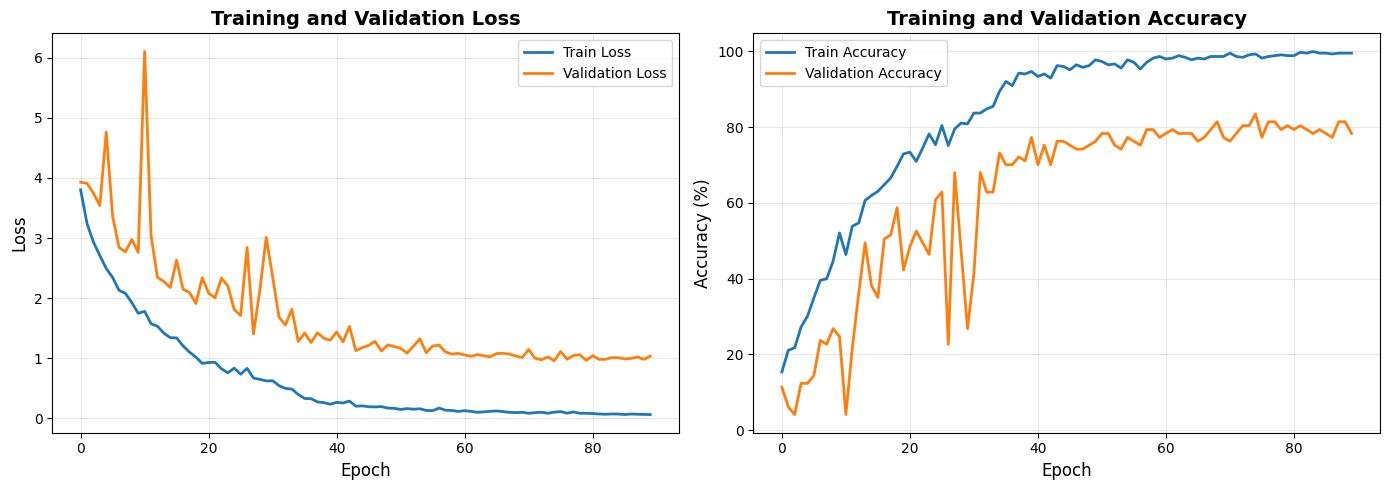


Training history plot saved as 'training_history.png'


In [ ]:
#--- Plotting training history ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
ax1.plot(train_losses, label='Train Loss', linewidth=2)
ax1.plot(val_losses, label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot(train_accs, label='Train Accuracy', linewidth=2)
ax2.plot(val_accs, label='Validation Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTraining history plot saved as 'training_history.png'")

In [ ]:
#--- Define test set from last fold and get predictions ---
# Use the last fold's validation data as test set
test_fold_idx = num_folds - 1
test_train_idx, test_val_idx = fold_indices[test_fold_idx]

test_subset = torch.utils.data.Subset(dataset, test_val_idx)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

# Load the best model from the last fold
best_model_result = fold_results[test_fold_idx]
model_filepath = os.path.join(results_folder, best_model_result['filename'])
model = ResNet1D(num_classes=dataset.num_classes).to(device)
model.load_state_dict(torch.load(model_filepath))

# Get predictions on test set
_, test_acc, test_predictions, test_labels = evaluate(model, test_loader, criterion, device)

# Get unique labels and corresponding species names
unique_labels = np.unique(test_labels)
target_names_test = [dataset.label_encoder.classes_[i] for i in unique_labels]

print(f"\n{'='*60}")
print(f"TEST SET EVALUATION")
print(f"{'='*60}")
print(f"Model: {best_model_result['filename']}")
print(f"Test samples: {len(test_val_idx)}")
print(f"Test accuracy: {test_acc:.2f}%")
print(f"Number of unique species in test set: {len(unique_labels)}")

#--- Top/Bottom Performing Species ---
from sklearn.metrics import precision_recall_fscore_support

# Calculate per-class metrics (precision, recall, f1-score)
precision, recall, f1, support = precision_recall_fscore_support(
    test_labels, 
    test_predictions, 
    labels=unique_labels,
    zero_division=0
)

# Create dataframe with species performance
species_performance = pd.DataFrame({
    'Species': target_names_test,
    'F1-Score': f1,
    'Precision': precision,
    'Recall': recall,
    'Support': support
})

# Sort by F1-score
species_performance = species_performance.sort_values('F1-Score', ascending=False)

# Get top 5 and bottom 5
top_5 = species_performance.head(5)
bottom_5 = species_performance.tail(5)

print("\n" + "="*70)
print("TOP 5 BEST PERFORMING SPECIES")
print("="*70)
print(top_5.to_string(index=False))

print("\n" + "="*70)
print("BOTTOM 5 WORST PERFORMING SPECIES")
print("="*70)
print(bottom_5.to_string(index=False))

# Plot top 5 and bottom 5
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top 5
top_5_sorted = top_5.sort_values('F1-Score', ascending=True)
colors_top = plt.cm.Greens(np.linspace(0.4, 0.8, len(top_5_sorted)))
ax1.barh(range(len(top_5_sorted)), top_5_sorted['F1-Score'], color=colors_top)
ax1.set_yticks(range(len(top_5_sorted)))
ax1.set_yticklabels(top_5_sorted['Species'], fontsize=10)
ax1.set_xlabel('F1-Score', fontsize=12)
ax1.set_title('Top 5 Best Performing Species', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 1)
ax1.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(top_5_sorted['F1-Score']):
    ax1.text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=10)

# Bottom 5
bottom_5_sorted = bottom_5.sort_values('F1-Score', ascending=True)
colors_bottom = plt.cm.Reds(np.linspace(0.4, 0.8, len(bottom_5_sorted)))
ax2.barh(range(len(bottom_5_sorted)), bottom_5_sorted['F1-Score'], color=colors_bottom)
ax2.set_yticks(range(len(bottom_5_sorted)))
ax2.set_yticklabels(bottom_5_sorted['Species'], fontsize=10)
ax2.set_xlabel('F1-Score', fontsize=12)
ax2.set_title('Bottom 5 Worst Performing Species', fontsize=14, fontweight='bold')
ax2.set_xlim(0, 1)
ax2.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(bottom_5_sorted['F1-Score']):
    ax2.text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('species_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSpecies performance plot saved as 'species_performance.png'")

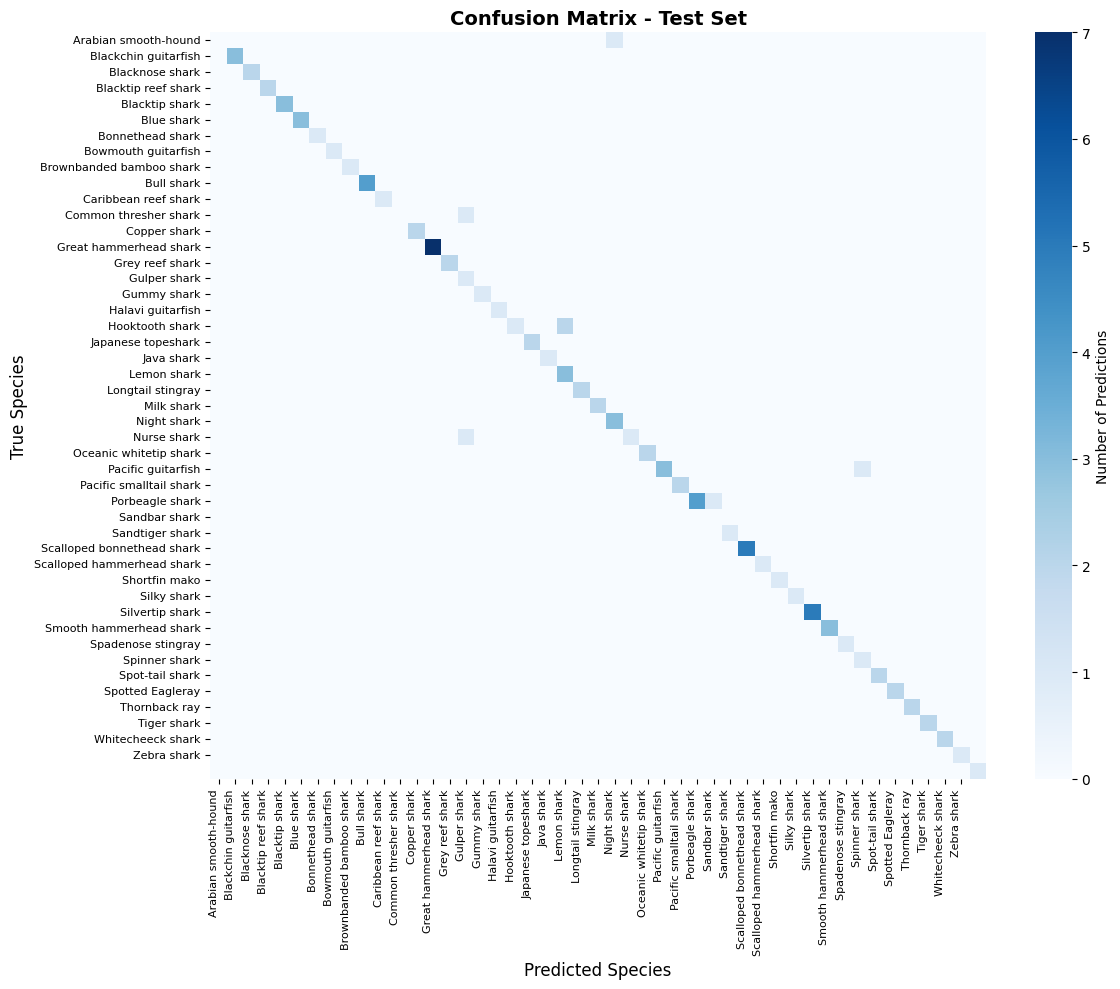

Confusion matrix saved as 'confusion_matrix.png'


In [ ]:
#--- Confusion matrix ---
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get confusion matrix for test set
cm = confusion_matrix(test_labels, test_predictions)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
            xticklabels=target_names_test, 
            yticklabels=target_names_test,
            cbar_kws={'label': 'Number of Predictions'})
plt.xlabel('Predicted Species', fontsize=12)
plt.ylabel('True Species', fontsize=12)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix saved as 'confusion_matrix.png'")